# 01 — EDA and Label Analysis

**Project:** Pedi-CGAM Lite  
**Dataset:** VinDr-PCXR  
**Platform:** Kaggle  
**Target hardware:** Single NVIDIA T4 GPU

## Purpose

Stage 00B passed, so the DICOM pipeline is now verified. This notebook performs the first real research analysis of the **official training set only**.

### Important test-set rule

The official test labels are intentionally **not loaded or analyzed here**.

We will use the official test set only after the complete model, thresholds, calibration, and abstention rules are frozen.

## This notebook will produce

- exact 15 image-level label frequencies
- pathology-only frequencies excluding `No finding`
- class prevalence and imbalance ratios
- multi-label statistics
- consistency check for `No finding`
- disease co-occurrence matrix
- head / middle / tail disease groups
- exact annotation/finding classes
- finding row frequency and boxed-image frequency
- finding head / middle / tail groups
- bounding-box counts and normalized box-size statistics
- image dimension statistics
- examples of X-rays with radiologist boxes
- research-ready figures and CSV tables
- a compact EDA report
- one final Kaggle ZIP containing all generated outputs

### Final Kaggle ZIP

`/kaggle/working/PediCGAM_Stage01_EDA_All_Outputs.zip`


In [1]:
# ============================================================
# 1. Install DICOM decoders BEFORE importing pydicom
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 19.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports, configuration, and reproducibility
# ============================================================
import os
import sys
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import pydicom

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_SEARCH_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/PediCGAM/stage01_eda")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pydicom:", pydicom.__version__)
print("Output directory:", OUTPUT_DIR)


Python: 3.12.13
pydicom: 3.0.2
Output directory: /kaggle/working/PediCGAM/stage01_eda


In [3]:
# ============================================================
# 3. Confirm Kaggle GPU (training will use it later)
# ============================================================
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        props = torch.cuda.get_device_properties(0)
        print(f"GPU memory: {props.total_memory / 1024**3:.2f} GB")
except Exception as e:
    print("GPU check error:", repr(e))


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [4]:
# ============================================================
# 4. Automatically locate VinDr-PCXR
# ============================================================
REQUIRED_TRAIN_FILES = {
    "image_labels_train.csv",
    "annotations_train.csv",
}

def find_vindr_root(search_root=DATA_SEARCH_ROOT):
    candidates = []
    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {p.name for p in folder.iterdir() if p.is_file()}
        score = len(REQUIRED_TRAIN_FILES.intersection(names))
        candidates.append((score, folder))
    candidates.sort(key=lambda x: (-x[0], len(str(x[1]))))
    return candidates

candidates = find_vindr_root()

if not candidates:
    raise FileNotFoundError(
        "VinDr-PCXR could not be found under /kaggle/input."
    )

DATA_ROOT = candidates[0][1]
TRAIN_DIR = DATA_ROOT / "train"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)

assert TRAIN_DIR.exists()


DATA_ROOT: /kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0
TRAIN_DIR: /kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


## Research integrity rule

From this point onward, **only these training metadata files are loaded**:

- `image_labels_train.csv`
- `annotations_train.csv`

The test-label CSVs are deliberately left untouched.


In [5]:
# ============================================================
# 5. Load OFFICIAL TRAINING metadata only
# ============================================================
labels_path = DATA_ROOT / "image_labels_train.csv"
annotations_path = DATA_ROOT / "annotations_train.csv"

labels = pd.read_csv(labels_path)
ann = pd.read_csv(annotations_path)

print("image_labels_train.csv:", labels.shape)
print("annotations_train.csv :", ann.shape)

print("\nImage-label columns:")
print(labels.columns.tolist())

print("\nAnnotation columns:")
print(ann.columns.tolist())

display(labels.head(3))
display(ann.head(3))


image_labels_train.csv: (7728, 17)
annotations_train.csv : (10371, 8)

Image-label columns:
['image_id', 'rad_ID', 'No finding', 'Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor']

Annotation columns:
['image_id', 'rad_ID', 'class_name', 'x_min', 'y_min', 'x_max', 'y_max', 'class_id']


,image_id,rad_ID,No finding,Bronchitis,Brocho-pneumonia,Other disease,Bronchiolitis,Situs inversus,Pneumonia,Pleuro-pneumonia,Diagphramatic hernia,Tuberculosis,Congenital emphysema,CPAM,Hyaline membrane disease,Mediastinal tumor,Lung tumor
0,6cb53aff85c71b98ad13d67a131708c6,R3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,40414c05687cdb156823c156967b13f0,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0e4a464dfbf8abc6333c82f1b77b6455,R3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,image_id,rad_ID,class_name,x_min,y_min,x_max,y_max,class_id
0,03d56a9709a81b2e9d6afbc6647c8730,R3,Boot-shaped heart,378.760010,401.416645,835.143248,661.678438,0
1,48f7ba0b0fd5ab847ee87df2aed5cfc9,R3,Peribronchovascular interstitial opacity,247.196368,412.000819,441.763442,830.320028,1
2,48f7ba0b0fd5ab847ee87df2aed5cfc9,R3,Peribronchovascular interstitial opacity,613.631024,364.980443,902.238850,827.077243,1


In [6]:
# ============================================================
# 6. Basic schema and data-quality checks
# ============================================================
expected_label_rows = 7728

quality = pd.DataFrame([
    {
        "table": "image_labels_train",
        "rows": len(labels),
        "columns": labels.shape[1],
        "duplicate_rows": int(labels.duplicated().sum()),
        "missing_cells": int(labels.isna().sum().sum()),
        "unique_image_ids": labels["image_id"].nunique(),
    },
    {
        "table": "annotations_train",
        "rows": len(ann),
        "columns": ann.shape[1],
        "duplicate_rows": int(ann.duplicated().sum()),
        "missing_cells": int(ann.isna().sum().sum()),
        "unique_image_ids": ann["image_id"].nunique(),
    }
])

display(quality)
quality.to_csv(TABLE_DIR / "data_quality_summary.csv", index=False)

assert labels["image_id"].nunique() == expected_label_rows
assert ann["image_id"].nunique() == expected_label_rows

print("✅ Every training image appears in both metadata tables.")


,table,rows,columns,duplicate_rows,missing_cells,unique_image_ids
0,image_labels_train,7728,17,0,0,7728
1,annotations_train,10371,8,0,20572,7728


✅ Every training image appears in both metadata tables.


# Part A — Image-level disease-label analysis

The dataset contains 15 image-level output columns after `image_id` and `rad_ID`.

We preserve the **exact original dataset spellings** in every CSV and model configuration. We do not silently rename labels during experiments.


In [7]:
# ============================================================
# 7. Identify the 15 image-level label columns
# ============================================================
NON_LABEL_COLUMNS = ["image_id", "rad_ID"]
LABEL_COLUMNS = [c for c in labels.columns if c not in NON_LABEL_COLUMNS]

print("Number of image-level label columns:", len(LABEL_COLUMNS))
for i, c in enumerate(LABEL_COLUMNS, 1):
    print(f"{i:02d}. {c}")

assert len(LABEL_COLUMNS) == 15, (
    f"Expected 15 label columns, found {len(LABEL_COLUMNS)}"
)

# Ensure labels are numeric/binary
label_matrix = labels[LABEL_COLUMNS].apply(pd.to_numeric, errors="coerce")

unique_values = sorted(
    pd.unique(label_matrix.values.ravel()[~pd.isna(label_matrix.values.ravel())])
)

print("\nUnique label values:", unique_values)

if not set(unique_values).issubset({0, 0.0, 1, 1.0}):
    print("⚠️ REVIEW: Non-binary values were found.")
else:
    print("✅ Image-level labels are binary.")


Number of image-level label columns: 15
01. No finding
02. Bronchitis
03. Brocho-pneumonia
04. Other disease
05. Bronchiolitis
06. Situs inversus
07. Pneumonia
08. Pleuro-pneumonia
09. Diagphramatic hernia
10. Tuberculosis
11. Congenital emphysema
12. CPAM
13. Hyaline membrane disease
14. Mediastinal tumor
15. Lung tumor

Unique label values: [np.float64(0.0), np.float64(1.0)]
✅ Image-level labels are binary.


In [8]:
# ============================================================
# 8. Disease/label frequency and prevalence
# ============================================================
N = len(labels)

positive_counts = label_matrix.sum(axis=0).astype(int)
prevalence = positive_counts / N

disease_frequency = pd.DataFrame({
    "label": LABEL_COLUMNS,
    "positive_images": [int(positive_counts[c]) for c in LABEL_COLUMNS],
    "negative_images": [int(N - positive_counts[c]) for c in LABEL_COLUMNS],
    "prevalence": [float(prevalence[c]) for c in LABEL_COLUMNS],
})

disease_frequency["prevalence_percent"] = (
    disease_frequency["prevalence"] * 100
)
disease_frequency["negative_to_positive_ratio"] = (
    disease_frequency["negative_images"] /
    disease_frequency["positive_images"].replace(0, np.nan)
)

disease_frequency = disease_frequency.sort_values(
    "positive_images",
    ascending=False
).reset_index(drop=True)

display(disease_frequency)
disease_frequency.to_csv(
    TABLE_DIR / "disease_label_frequency.csv",
    index=False
)


,label,positive_images,negative_images,prevalence,prevalence_percent,negative_to_positive_ratio
0,No finding,5143,2585,0.665502,66.550207,0.502625
1,Bronchitis,842,6886,0.108954,10.895445,8.178147
2,Brocho-pneumonia,545,7183,0.070523,7.052277,13.179817
3,Bronchiolitis,497,7231,0.064312,6.431159,14.549296
4,Other disease,412,7316,0.053313,5.331263,17.757282
5,Pneumonia,392,7336,0.050725,5.072464,18.714286
6,Hyaline membrane disease,19,7709,0.002459,0.245859,405.736842
7,Tuberculosis,14,7714,0.001812,0.181159,551.000000
8,Situs inversus,11,7717,0.001423,0.142340,701.545455
9,Mediastinal tumor,8,7720,0.001035,0.103520,965.000000


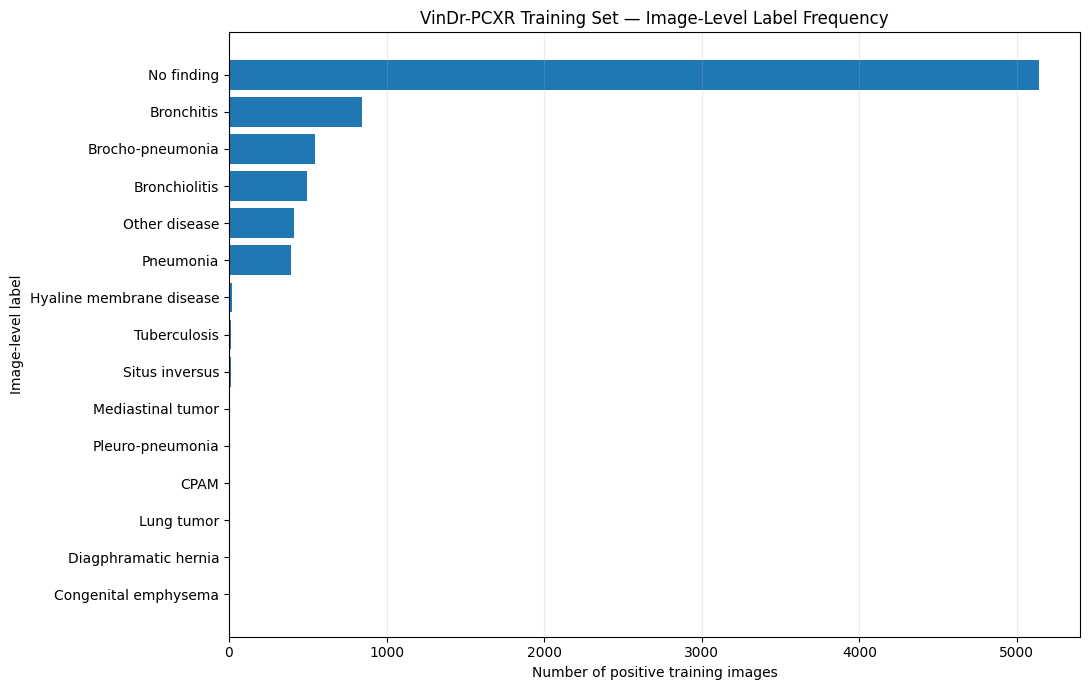

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/01_disease_label_frequency.png


In [9]:
# ============================================================
# 9. Figure — image-level label frequency
# ============================================================
plot_df = disease_frequency.sort_values("positive_images")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["label"], plot_df["positive_images"])
ax.set_xlabel("Number of positive training images")
ax.set_ylabel("Image-level label")
ax.set_title("VinDr-PCXR Training Set — Image-Level Label Frequency")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "01_disease_label_frequency.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


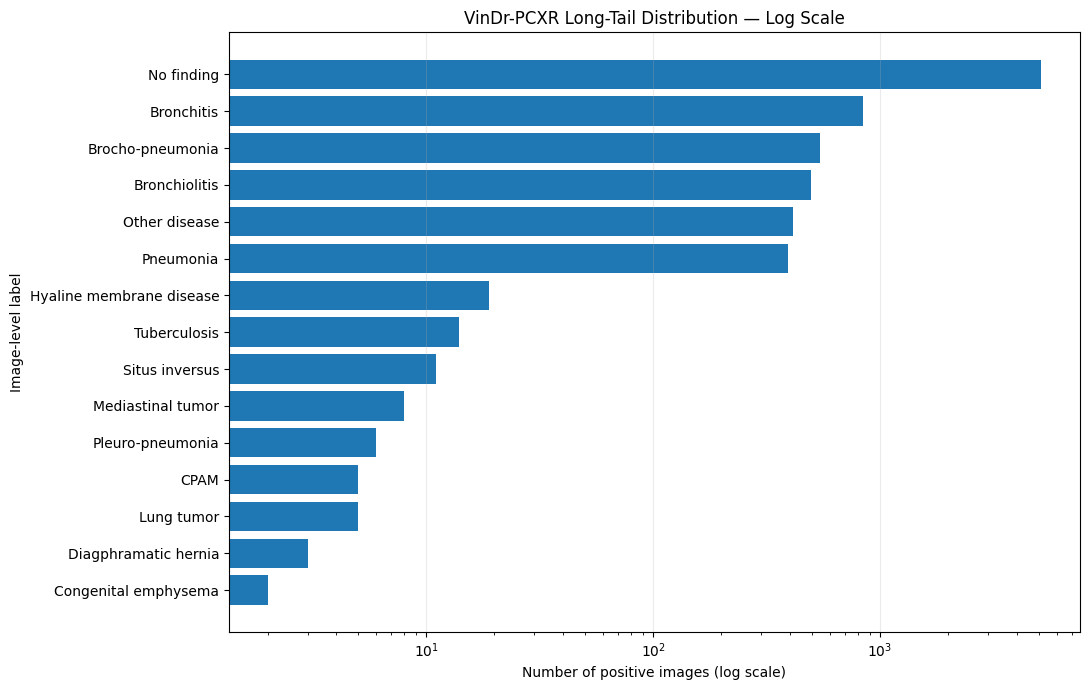

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/02_disease_label_frequency_log_scale.png


In [10]:
# ============================================================
# 10. Figure — log-scale label frequency
# ============================================================
plot_df = disease_frequency.sort_values("positive_images")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["label"], plot_df["positive_images"])
ax.set_xscale("log")
ax.set_xlabel("Number of positive images (log scale)")
ax.set_ylabel("Image-level label")
ax.set_title("VinDr-PCXR Long-Tail Distribution — Log Scale")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "02_disease_label_frequency_log_scale.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [11]:
# ============================================================
# 11. Check the special 'No finding' label
# ============================================================
if "No finding" not in LABEL_COLUMNS:
    raise KeyError("'No finding' label not found.")

PATHOLOGY_COLUMNS = [c for c in LABEL_COLUMNS if c != "No finding"]

no_finding = label_matrix["No finding"] == 1
any_pathology = label_matrix[PATHOLOGY_COLUMNS].sum(axis=1) > 0

no_finding_with_pathology = int((no_finding & any_pathology).sum())
no_finding_only = int((no_finding & ~any_pathology).sum())
pathology_without_no_finding = int((~no_finding & any_pathology).sum())
neither = int((~no_finding & ~any_pathology).sum())

no_finding_check = pd.DataFrame([
    {"category": "No finding = 1, no pathology label = 1",
     "images": no_finding_only},
    {"category": "No finding = 1 AND pathology label(s) = 1",
     "images": no_finding_with_pathology},
    {"category": "No finding = 0, pathology label(s) = 1",
     "images": pathology_without_no_finding},
    {"category": "No finding = 0, no pathology label = 1",
     "images": neither},
])

display(no_finding_check)
no_finding_check.to_csv(
    TABLE_DIR / "no_finding_consistency_check.csv",
    index=False
)

if no_finding_with_pathology == 0:
    print("✅ 'No finding' is mutually exclusive with pathology labels in training data.")
else:
    print(
        f"⚠️ REVIEW: {no_finding_with_pathology} images have both "
        "'No finding' and at least one pathology label."
    )


,category,images
0,"No finding = 1, no pathology label = 1",5143
1,No finding = 1 AND pathology label(s) = 1,0
2,"No finding = 0, pathology label(s) = 1",2531
3,"No finding = 0, no pathology label = 1",54


✅ 'No finding' is mutually exclusive with pathology labels in training data.


In [12]:
# ============================================================
# 12. Multi-label statistics
# ============================================================
labels_per_image_all = label_matrix.sum(axis=1).astype(int)
pathologies_per_image = label_matrix[PATHOLOGY_COLUMNS].sum(axis=1).astype(int)

multilabel_summary = pd.DataFrame([
    {
        "metric": "training_images",
        "value": len(labels),
    },
    {
        "metric": "mean_all_positive_labels_per_image",
        "value": float(labels_per_image_all.mean()),
    },
    {
        "metric": "max_all_positive_labels_per_image",
        "value": int(labels_per_image_all.max()),
    },
    {
        "metric": "mean_pathology_labels_per_image",
        "value": float(pathologies_per_image.mean()),
    },
    {
        "metric": "max_pathology_labels_per_image",
        "value": int(pathologies_per_image.max()),
    },
    {
        "metric": "images_with_multiple_pathologies",
        "value": int((pathologies_per_image >= 2).sum()),
    },
    {
        "metric": "images_with_3plus_pathologies",
        "value": int((pathologies_per_image >= 3).sum()),
    },
])

display(multilabel_summary)
multilabel_summary.to_csv(
    TABLE_DIR / "multilabel_summary.csv",
    index=False
)

pathology_count_distribution = (
    pathologies_per_image.value_counts()
    .sort_index()
    .rename_axis("number_of_pathology_labels")
    .reset_index(name="images")
)

display(pathology_count_distribution)
pathology_count_distribution.to_csv(
    TABLE_DIR / "pathologies_per_image_distribution.csv",
    index=False
)


,metric,value
0,training_images,7728.000000
1,mean_all_positive_labels_per_image,1.022774
2,max_all_positive_labels_per_image,4.000000
3,mean_pathology_labels_per_image,0.357272
4,max_pathology_labels_per_image,4.000000
5,images_with_multiple_pathologies,223.000000
6,images_with_3plus_pathologies,6.000000


,number_of_pathology_labels,images
0,0,5197
1,1,2308
2,2,217
3,3,5
4,4,1


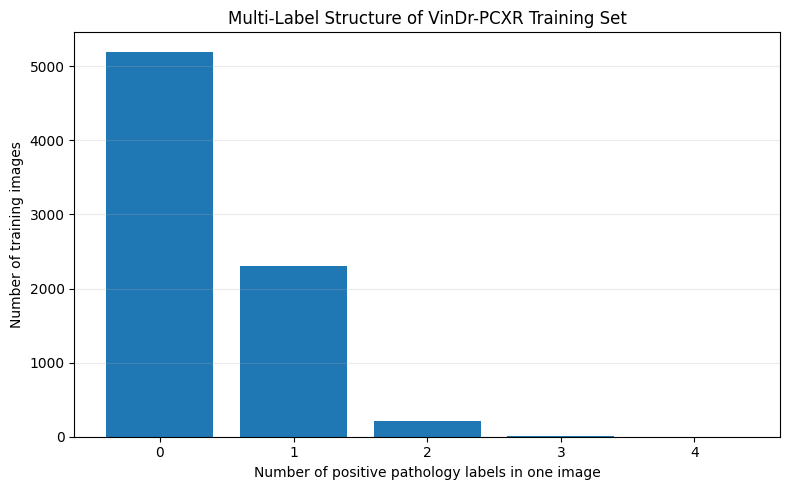

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/03_pathologies_per_image.png


In [13]:
# ============================================================
# 13. Figure — pathology labels per image
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    pathology_count_distribution["number_of_pathology_labels"].astype(str),
    pathology_count_distribution["images"]
)
ax.set_xlabel("Number of positive pathology labels in one image")
ax.set_ylabel("Number of training images")
ax.set_title("Multi-Label Structure of VinDr-PCXR Training Set")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "03_pathologies_per_image.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [14]:
# ============================================================
# 14. Pathology-only frequencies
# ============================================================
pathology_frequency = disease_frequency[
    disease_frequency["label"] != "No finding"
].copy().reset_index(drop=True)

display(pathology_frequency)

pathology_frequency.to_csv(
    TABLE_DIR / "pathology_only_frequency.csv",
    index=False
)


,label,positive_images,negative_images,prevalence,prevalence_percent,negative_to_positive_ratio
0,Bronchitis,842,6886,0.108954,10.895445,8.178147
1,Brocho-pneumonia,545,7183,0.070523,7.052277,13.179817
2,Bronchiolitis,497,7231,0.064312,6.431159,14.549296
3,Other disease,412,7316,0.053313,5.331263,17.757282
4,Pneumonia,392,7336,0.050725,5.072464,18.714286
5,Hyaline membrane disease,19,7709,0.002459,0.245859,405.736842
6,Tuberculosis,14,7714,0.001812,0.181159,551.000000
7,Situs inversus,11,7717,0.001423,0.142340,701.545455
8,Mediastinal tumor,8,7720,0.001035,0.103520,965.000000
9,Pleuro-pneumonia,6,7722,0.000776,0.077640,1287.000000


In [15]:
# ============================================================
# 15. Define head / middle / tail groups
# ============================================================
# Operational 15-label grouping:
# 5 most frequent, next 5, 5 least frequent.
#
# Scientific pathology-only grouping:
# We also save a separate grouping excluding 'No finding',
# because 'No finding' is not a disease.

def assign_three_groups(sorted_df, label_col="label"):
    n = len(sorted_df)

    if n == 15:
        sizes = [5, 5, 5]
    else:
        # As equal as possible for any other number of classes.
        base = n // 3
        rem = n % 3
        sizes = [base + (1 if i < rem else 0) for i in range(3)]

    group_names = (
        ["Head"] * sizes[0] +
        ["Middle"] * sizes[1] +
        ["Tail"] * sizes[2]
    )

    out = sorted_df.copy().reset_index(drop=True)
    out["rarity_group"] = group_names[:len(out)]
    out["frequency_rank"] = np.arange(1, len(out) + 1)
    return out

all15_groups = assign_three_groups(disease_frequency)
pathology_groups = assign_three_groups(pathology_frequency)

print("15-label operational grouping:")
display(all15_groups[
    ["frequency_rank", "label", "positive_images",
     "prevalence_percent", "rarity_group"]
])

print("\nPathology-only grouping:")
display(pathology_groups[
    ["frequency_rank", "label", "positive_images",
     "prevalence_percent", "rarity_group"]
])

all15_groups.to_csv(
    TABLE_DIR / "head_middle_tail_all15_labels.csv",
    index=False
)
pathology_groups.to_csv(
    TABLE_DIR / "head_middle_tail_pathology_only.csv",
    index=False
)


15-label operational grouping:


,frequency_rank,label,positive_images,prevalence_percent,rarity_group
0,1,No finding,5143,66.550207,Head
1,2,Bronchitis,842,10.895445,Head
2,3,Brocho-pneumonia,545,7.052277,Head
3,4,Bronchiolitis,497,6.431159,Head
4,5,Other disease,412,5.331263,Head
5,6,Pneumonia,392,5.072464,Middle
6,7,Hyaline membrane disease,19,0.245859,Middle
7,8,Tuberculosis,14,0.181159,Middle
8,9,Situs inversus,11,0.142340,Middle
9,10,Mediastinal tumor,8,0.103520,Middle



Pathology-only grouping:


,frequency_rank,label,positive_images,prevalence_percent,rarity_group
0,1,Bronchitis,842,10.895445,Head
1,2,Brocho-pneumonia,545,7.052277,Head
2,3,Bronchiolitis,497,6.431159,Head
3,4,Other disease,412,5.331263,Head
4,5,Pneumonia,392,5.072464,Head
5,6,Hyaline membrane disease,19,0.245859,Middle
6,7,Tuberculosis,14,0.181159,Middle
7,8,Situs inversus,11,0.142340,Middle
8,9,Mediastinal tumor,8,0.103520,Middle
9,10,Pleuro-pneumonia,6,0.077640,Middle


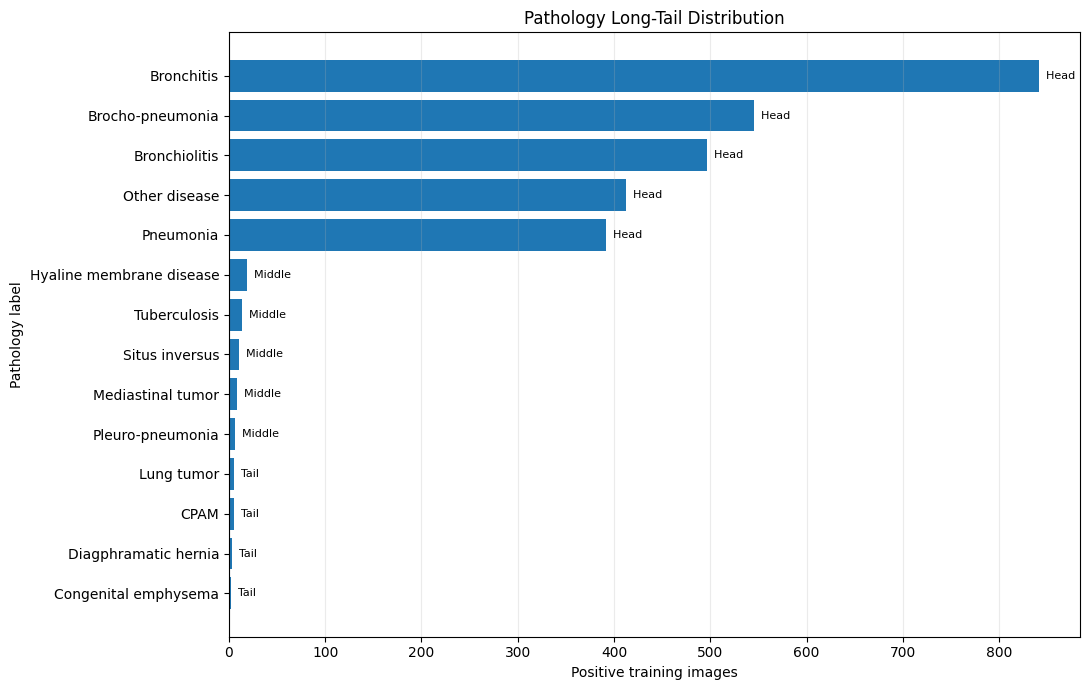

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/04_pathology_head_middle_tail.png


In [16]:
# ============================================================
# 16. Figure — head / middle / tail pathology groups
# ============================================================
plot_df = pathology_groups.sort_values("positive_images")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["label"], plot_df["positive_images"])
ax.set_xlabel("Positive training images")
ax.set_ylabel("Pathology label")
ax.set_title("Pathology Long-Tail Distribution")
ax.grid(axis="x", alpha=0.25)

# Add group text at the end of each bar without changing bar colors.
for y, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["positive_images"],
        y,
        f"  {row['rarity_group']}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
path = FIG_DIR / "04_pathology_head_middle_tail.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


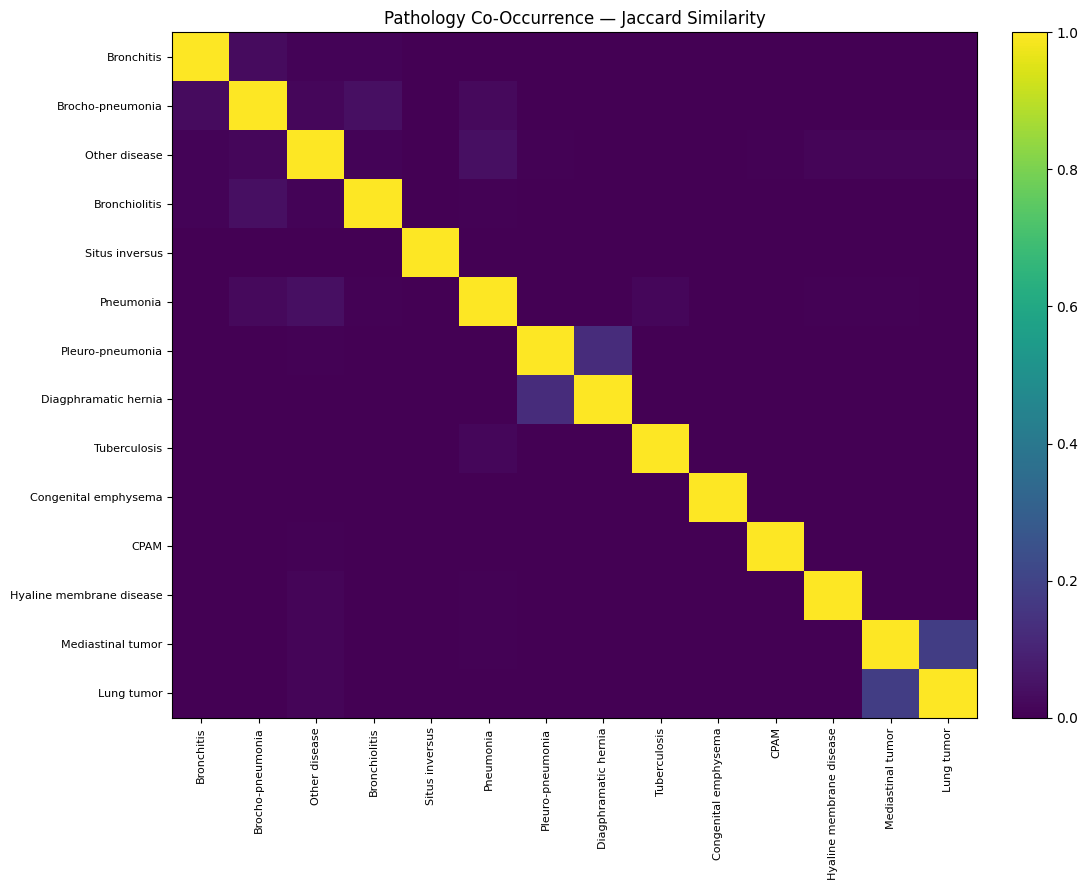

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/05_pathology_cooccurrence_heatmap.png


In [17]:
# ============================================================
# 17. Disease/pathology co-occurrence matrix
# ============================================================
# Use pathology labels only so 'No finding' does not dominate.
P = label_matrix[PATHOLOGY_COLUMNS].astype(int)

cooccurrence = P.T.dot(P)
cooccurrence.index.name = "label"
cooccurrence.to_csv(TABLE_DIR / "pathology_cooccurrence_counts.csv")

# Jaccard-like pairwise co-occurrence normalization:
# intersection / union
counts = P.sum(axis=0).values
intersection = cooccurrence.values.astype(float)
union = counts[:, None] + counts[None, :] - intersection
jaccard = np.divide(
    intersection,
    union,
    out=np.zeros_like(intersection),
    where=union > 0
)

jaccard_df = pd.DataFrame(
    jaccard,
    index=PATHOLOGY_COLUMNS,
    columns=PATHOLOGY_COLUMNS
)
jaccard_df.index.name = "label"
jaccard_df.to_csv(
    TABLE_DIR / "pathology_cooccurrence_jaccard.csv"
)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(jaccard_df.values, aspect="auto")
ax.set_xticks(np.arange(len(PATHOLOGY_COLUMNS)))
ax.set_yticks(np.arange(len(PATHOLOGY_COLUMNS)))
ax.set_xticklabels(PATHOLOGY_COLUMNS, rotation=90, fontsize=8)
ax.set_yticklabels(PATHOLOGY_COLUMNS, fontsize=8)
ax.set_title("Pathology Co-Occurrence — Jaccard Similarity")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
path = FIG_DIR / "05_pathology_cooccurrence_heatmap.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


# Part B — Radiological finding and bounding-box analysis

`annotations_train.csv` contains one or more annotation rows per image.

Some rows have box coordinates and some have missing coordinates. We will **not assume** that missing coordinates are errors. Instead, we analyze:

- total annotation rows per class
- unique images per class
- rows with valid boxes
- unique boxed images per class
- rows without boxes

This tells us which findings are suitable for box-guided attention.


In [18]:
# ============================================================
# 18. Annotation and box validity flags
# ============================================================
BOX_COLS = ["x_min", "y_min", "x_max", "y_max"]

numeric_boxes = ann[BOX_COLS].apply(pd.to_numeric, errors="coerce")

ann = ann.copy()
ann["has_box"] = numeric_boxes.notna().all(axis=1)

ann["valid_box_geometry"] = (
    ann["has_box"]
    & (numeric_boxes["x_max"] > numeric_boxes["x_min"])
    & (numeric_boxes["y_max"] > numeric_boxes["y_min"])
    & (numeric_boxes[BOX_COLS] >= 0).all(axis=1)
)

annotation_summary = pd.DataFrame([
    {"metric": "annotation_rows", "value": len(ann)},
    {"metric": "unique_images", "value": ann["image_id"].nunique()},
    {"metric": "unique_class_names", "value": ann["class_name"].nunique()},
    {"metric": "rows_with_box", "value": int(ann["has_box"].sum())},
    {"metric": "rows_without_box", "value": int((~ann["has_box"]).sum())},
    {"metric": "invalid_box_geometry_rows",
     "value": int((ann["has_box"] & ~ann["valid_box_geometry"]).sum())},
    {"metric": "unique_images_with_at_least_one_box",
     "value": ann.loc[ann["has_box"], "image_id"].nunique()},
])

display(annotation_summary)
annotation_summary.to_csv(
    TABLE_DIR / "annotation_summary.csv",
    index=False
)


,metric,value
0,annotation_rows,10371
1,unique_images,7728
2,unique_class_names,37
3,rows_with_box,5228
4,rows_without_box,5143
5,invalid_box_geometry_rows,0
6,unique_images_with_at_least_one_box,2585


In [19]:
# ============================================================
# 19. Exact radiological finding/class list
# ============================================================
finding_frequency = (
    ann.groupby(["class_id", "class_name"], dropna=False)
    .agg(
        annotation_rows=("image_id", "size"),
        unique_images=("image_id", "nunique"),
        boxed_rows=("has_box", "sum"),
        boxed_images=("image_id", lambda s: s[ann.loc[s.index, "has_box"]].nunique()),
    )
    .reset_index()
)

finding_frequency["rows_without_box"] = (
    finding_frequency["annotation_rows"]
    - finding_frequency["boxed_rows"]
)

finding_frequency["box_row_fraction"] = (
    finding_frequency["boxed_rows"]
    / finding_frequency["annotation_rows"].replace(0, np.nan)
)

finding_frequency = finding_frequency.sort_values(
    ["boxed_images", "unique_images"],
    ascending=False
).reset_index(drop=True)

print("Exact number of annotation classes:", len(finding_frequency))
display(finding_frequency)

finding_frequency.to_csv(
    TABLE_DIR / "finding_frequency_and_box_coverage.csv",
    index=False
)


Exact number of annotation classes: 37


,class_id,class_name,annotation_rows,unique_images,boxed_rows,boxed_images,rows_without_box,box_row_fraction
0,1,Peribronchovascular interstitial opacity,2315,1358,2315,1358,0,1.0
1,3,Bronchial thickening,794,562,794,562,0,1.0
2,2,Reticulonodular opacity,846,509,846,509,0,1.0
3,10,Consolidation,197,176,197,176,0,1.0
4,5,Cardiomegaly,162,161,162,161,0,1.0
5,6,Other opacity,187,148,187,148,0,1.0
6,8,Diffuse aveolar opacity,173,119,173,119,0,1.0
7,21,Lung hyperinflation,199,108,199,108,0,1.0
8,9,Other lesion,71,65,71,65,0,1.0
9,4,Enlarged PA,61,61,61,61,0,1.0


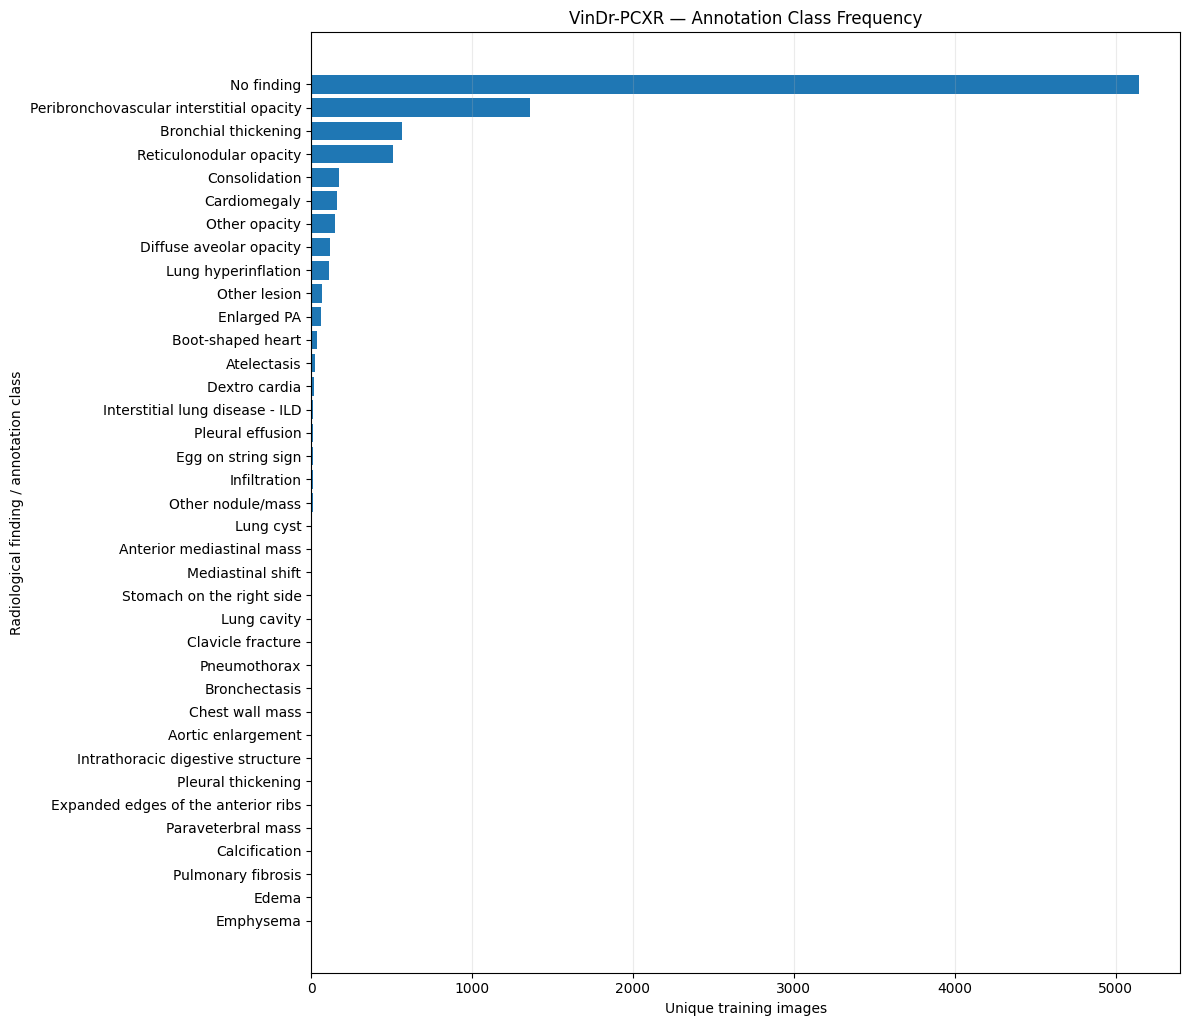

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/06_finding_unique_image_frequency.png


In [20]:
# ============================================================
# 20. Figure — annotation class frequency
# ============================================================
plot_df = finding_frequency.sort_values("unique_images")

fig, ax = plt.subplots(figsize=(12, max(7, 0.28 * len(plot_df))))
ax.barh(plot_df["class_name"], plot_df["unique_images"])
ax.set_xlabel("Unique training images")
ax.set_ylabel("Radiological finding / annotation class")
ax.set_title("VinDr-PCXR — Annotation Class Frequency")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "06_finding_unique_image_frequency.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


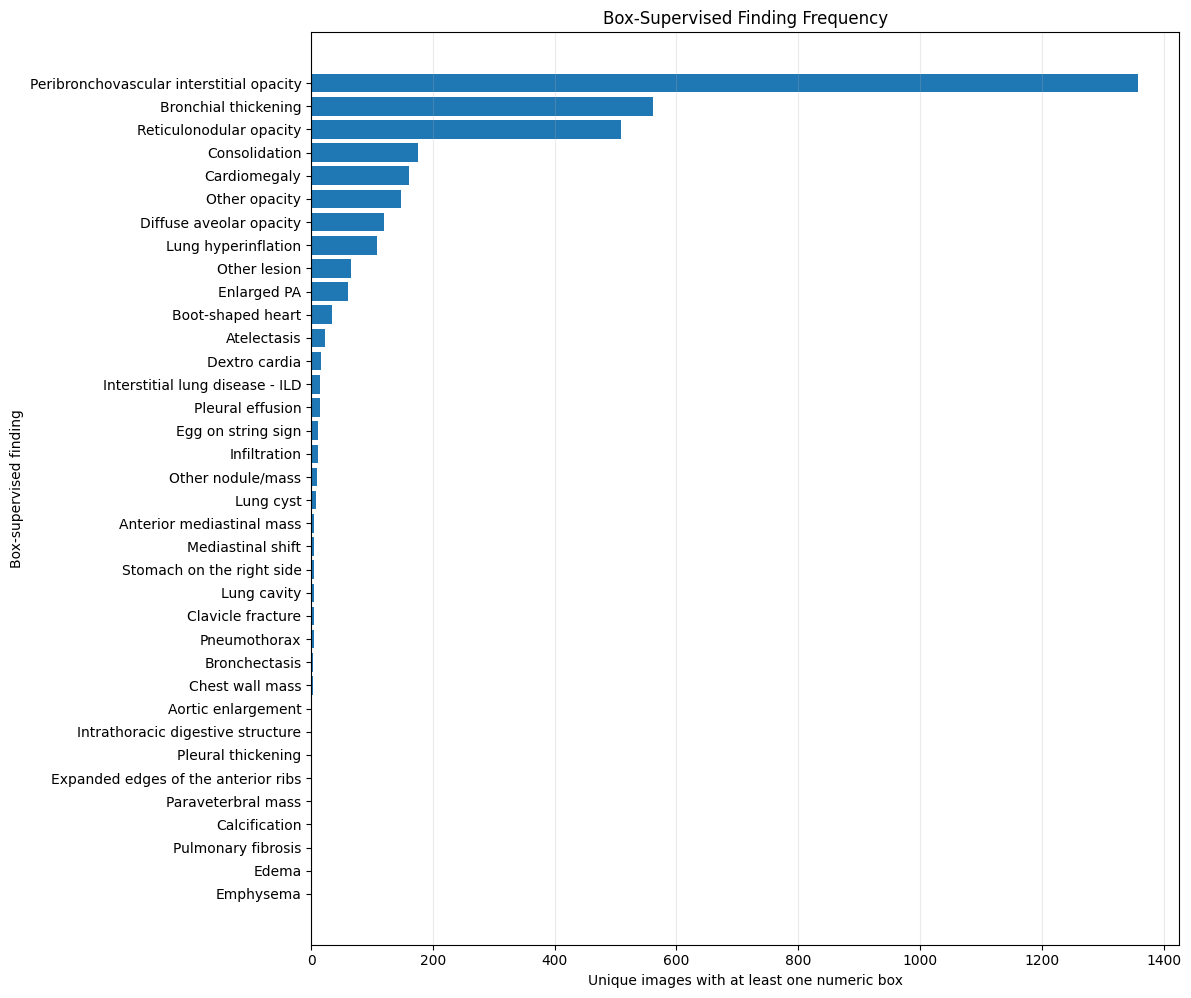

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/07_boxed_finding_frequency.png


In [21]:
# ============================================================
# 21. Figure — boxed-image frequency by finding
# ============================================================
boxed_findings = finding_frequency[
    finding_frequency["boxed_images"] > 0
].copy()

plot_df = boxed_findings.sort_values("boxed_images")

fig, ax = plt.subplots(figsize=(12, max(7, 0.28 * len(plot_df))))
ax.barh(plot_df["class_name"], plot_df["boxed_images"])
ax.set_xlabel("Unique images with at least one numeric box")
ax.set_ylabel("Box-supervised finding")
ax.set_title("Box-Supervised Finding Frequency")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "07_boxed_finding_frequency.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [22]:
# ============================================================
# 22. Head / middle / tail groups for box-supervised findings
# ============================================================
boxed_sorted = boxed_findings.sort_values(
    "boxed_images",
    ascending=False
).reset_index(drop=True)

finding_groups = assign_three_groups(
    boxed_sorted.rename(columns={"class_name": "label"})
).rename(columns={"label": "class_name"})

display(
    finding_groups[
        ["frequency_rank", "class_id", "class_name",
         "boxed_images", "boxed_rows", "rarity_group"]
    ]
)

finding_groups.to_csv(
    TABLE_DIR / "head_middle_tail_boxed_findings.csv",
    index=False
)


,frequency_rank,class_id,class_name,boxed_images,boxed_rows,rarity_group
0,1,1,Peribronchovascular interstitial opacity,1358,2315,Head
1,2,3,Bronchial thickening,562,794,Head
2,3,2,Reticulonodular opacity,509,846,Head
3,4,10,Consolidation,176,197,Head
4,5,5,Cardiomegaly,161,162,Head
5,6,6,Other opacity,148,187,Head
6,7,8,Diffuse aveolar opacity,119,173,Head
7,8,21,Lung hyperinflation,108,199,Head
8,9,9,Other lesion,65,71,Head
9,10,4,Enlarged PA,61,61,Head


In [23]:
# ============================================================
# 23. Read DICOM dimensions for all TRAIN images (metadata only)
# ============================================================
train_paths = {
    p.stem: p
    for p in TRAIN_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".dicom", ".dcm"}
}

dimension_rows = []

for image_id in tqdm(labels["image_id"].tolist(), desc="Reading DICOM dimensions"):
    path = train_paths.get(str(image_id))

    row = {
        "image_id": image_id,
        "rows": None,
        "columns": None,
        "photometric": None,
        "transfer_syntax_name": None,
        "metadata_ok": False,
        "error": None,
    }

    if path is None:
        row["error"] = "DICOM file not found"
    else:
        try:
            ds = pydicom.dcmread(
                str(path),
                stop_before_pixels=True
            )
            ts = ds.file_meta.TransferSyntaxUID

            row.update({
                "rows": int(ds.Rows),
                "columns": int(ds.Columns),
                "photometric": getattr(
                    ds,
                    "PhotometricInterpretation",
                    None
                ),
                "transfer_syntax_name": getattr(
                    ts,
                    "name",
                    str(ts)
                ),
                "metadata_ok": True,
            })
        except Exception as e:
            row["error"] = f"{type(e).__name__}: {e}"[:1000]

    dimension_rows.append(row)

dimensions = pd.DataFrame(dimension_rows)
dimensions.to_csv(
    TABLE_DIR / "train_dicom_dimensions.csv",
    index=False
)

print("Dimension metadata failures:",
      int((~dimensions["metadata_ok"]).sum()))

dimension_stats = pd.DataFrame([
    {"metric": "min_height", "value": dimensions["rows"].min()},
    {"metric": "median_height", "value": dimensions["rows"].median()},
    {"metric": "max_height", "value": dimensions["rows"].max()},
    {"metric": "min_width", "value": dimensions["columns"].min()},
    {"metric": "median_width", "value": dimensions["columns"].median()},
    {"metric": "max_width", "value": dimensions["columns"].max()},
])

display(dimension_stats)
dimension_stats.to_csv(
    TABLE_DIR / "image_dimension_statistics.csv",
    index=False
)


Reading DICOM dimensions:   0%|          | 0/7728 [00:00<?, ?it/s]

Dimension metadata failures: 0


,metric,value
0,min_height,704.0
1,median_height,1689.0
2,max_height,3230.0
3,min_width,681.0
4,median_width,1352.0
5,max_width,3072.0


In [24]:
# ============================================================
# 24. Bounding-box size statistics
# ============================================================
valid_boxes = ann[ann["valid_box_geometry"]].copy()
valid_boxes = valid_boxes.merge(
    dimensions[["image_id", "rows", "columns"]],
    on="image_id",
    how="left"
)

valid_boxes["box_width"] = (
    valid_boxes["x_max"] - valid_boxes["x_min"]
)
valid_boxes["box_height"] = (
    valid_boxes["y_max"] - valid_boxes["y_min"]
)
valid_boxes["box_area"] = (
    valid_boxes["box_width"] * valid_boxes["box_height"]
)
valid_boxes["image_area"] = (
    valid_boxes["rows"] * valid_boxes["columns"]
)
valid_boxes["normalized_box_area"] = (
    valid_boxes["box_area"] /
    valid_boxes["image_area"].replace(0, np.nan)
)

valid_boxes["normalized_box_width"] = (
    valid_boxes["box_width"] /
    valid_boxes["columns"].replace(0, np.nan)
)
valid_boxes["normalized_box_height"] = (
    valid_boxes["box_height"] /
    valid_boxes["rows"].replace(0, np.nan)
)

box_stats = valid_boxes[
    [
        "box_width",
        "box_height",
        "box_area",
        "normalized_box_width",
        "normalized_box_height",
        "normalized_box_area",
    ]
].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

display(box_stats)
box_stats.to_csv(TABLE_DIR / "bounding_box_size_statistics.csv")

valid_boxes[
    [
        "image_id", "rad_ID", "class_id", "class_name",
        "x_min", "y_min", "x_max", "y_max",
        "rows", "columns",
        "normalized_box_width",
        "normalized_box_height",
        "normalized_box_area",
    ]
].to_csv(
    TABLE_DIR / "valid_boxes_with_normalized_sizes.csv",
    index=False
)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
box_width,5228.0,187.784601,119.507153,10.989024,27.964032,54.939510,107.809120,158.621181,240.037682,414.240158,613.220571,1.687444e+03
box_height,5228.0,272.550443,167.470042,14.047888,26.239537,52.001110,135.583405,233.609481,400.189374,566.089546,692.524466,1.142653e+03
box_area,5228.0,63545.564885,71168.630586,217.365564,776.715482,3110.746695,15422.316857,38607.129659,93477.785832,192094.579984,285523.868235,1.734451e+06
normalized_box_width,5228.0,0.143631,0.092503,0.009037,0.020527,0.038271,0.078467,0.120471,0.189323,0.324117,0.476879,8.445667e-01
normalized_box_height,5228.0,0.172840,0.107439,0.008501,0.015681,0.031234,0.081934,0.145669,0.265550,0.352457,0.419291,6.567048e-01
normalized_box_area,5228.0,0.031111,0.032714,0.000111,0.000334,0.001327,0.006815,0.018386,0.048078,0.093042,0.142659,3.899792e-01


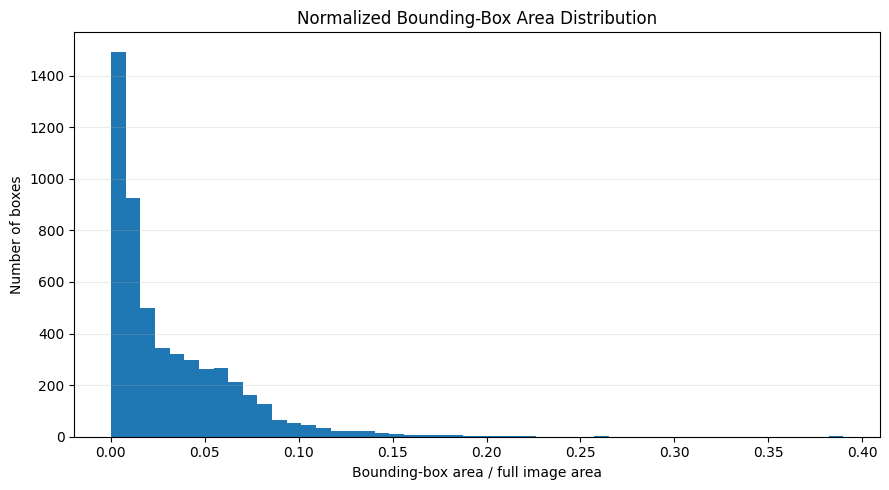

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/08_normalized_bounding_box_area.png


In [25]:
# ============================================================
# 25. Figure — normalized bounding-box area
# ============================================================
box_area_values = valid_boxes["normalized_box_area"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(box_area_values, bins=50)
ax.set_xlabel("Bounding-box area / full image area")
ax.set_ylabel("Number of boxes")
ax.set_title("Normalized Bounding-Box Area Distribution")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "08_normalized_bounding_box_area.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [26]:
# ============================================================
# 26. Box-size statistics by finding
# ============================================================
box_stats_by_finding = (
    valid_boxes.groupby(["class_id", "class_name"])
    .agg(
        boxes=("image_id", "size"),
        unique_images=("image_id", "nunique"),
        median_normalized_area=("normalized_box_area", "median"),
        mean_normalized_area=("normalized_box_area", "mean"),
        p10_normalized_area=(
            "normalized_box_area",
            lambda s: s.quantile(0.10)
        ),
        p90_normalized_area=(
            "normalized_box_area",
            lambda s: s.quantile(0.90)
        ),
    )
    .reset_index()
    .sort_values("boxes", ascending=False)
)

display(box_stats_by_finding)
box_stats_by_finding.to_csv(
    TABLE_DIR / "bounding_box_stats_by_finding.csv",
    index=False
)


,class_id,class_name,boxes,unique_images,median_normalized_area,mean_normalized_area,p10_normalized_area,p90_normalized_area
1,1,Peribronchovascular interstitial opacity,2315,1358,0.024979,0.031491,0.005953,0.065693
2,2,Reticulonodular opacity,846,509,0.023996,0.035900,0.004509,0.082531
3,3,Bronchial thickening,794,562,0.003021,0.005128,0.000403,0.012169
21,21,Lung hyperinflation,199,108,0.018917,0.022092,0.002494,0.039641
10,10,Consolidation,197,176,0.015772,0.018659,0.001826,0.038364
6,6,Other opacity,187,148,0.012917,0.018253,0.002565,0.041821
8,8,Diffuse aveolar opacity,173,119,0.047835,0.048414,0.004373,0.103562
5,5,Cardiomegaly,162,161,0.117954,0.117328,0.065839,0.171822
9,9,Other lesion,71,65,0.029533,0.033480,0.004674,0.063347
4,4,Enlarged PA,61,61,0.016436,0.017326,0.007904,0.027488


# Part C — Visual sanity check with radiologist boxes

We will show examples from both frequent and rare **box-supervised findings**.

The images are displayed correctly for `MONOCHROME1` and `MONOCHROME2`.

These visualizations are for EDA only; the final model preprocessing pipeline will be frozen later.


In [27]:
# ============================================================
# 27. DICOM display helper
# ============================================================
def normalize_for_display(pixel_array, photometric):
    arr = np.asarray(pixel_array, dtype=np.float32)

    lo, hi = np.percentile(arr, [1, 99])

    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(arr))
        hi = float(np.nanmax(arr))

    if hi > lo:
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr)

    arr = np.clip(arr, 0, 1)

    if str(photometric).upper() == "MONOCHROME1":
        arr = 1.0 - arr

    return arr

def load_dicom_for_display(image_id):
    path = train_paths[str(image_id)]
    ds = pydicom.dcmread(str(path))
    arr = ds.pixel_array
    image = normalize_for_display(
        arr,
        getattr(ds, "PhotometricInterpretation", None)
    )
    return image, ds


In [28]:
# ============================================================
# 28. Select common and rare boxed findings for visualization
# ============================================================
if len(finding_groups) == 0:
    raise RuntimeError("No boxed findings were found.")

head_names = finding_groups[
    finding_groups["rarity_group"] == "Head"
]["class_name"].tolist()

tail_names = finding_groups[
    finding_groups["rarity_group"] == "Tail"
]["class_name"].tolist()

selected_classes = []

for name in head_names[:3]:
    selected_classes.append(("Head", name))

for name in tail_names[-3:]:
    selected_classes.append(("Tail", name))

sample_manifest = []

for rarity_group, class_name in selected_classes:
    candidates = valid_boxes[
        valid_boxes["class_name"] == class_name
    ]["image_id"].drop_duplicates().tolist()

    if candidates:
        image_id = random.Random(SEED + len(sample_manifest)).choice(candidates)
        sample_manifest.append({
            "rarity_group": rarity_group,
            "class_name": class_name,
            "image_id": image_id,
        })

sample_manifest_df = pd.DataFrame(sample_manifest)
display(sample_manifest_df)

sample_manifest_df.to_csv(
    TABLE_DIR / "box_visualization_sample_manifest.csv",
    index=False
)


,rarity_group,class_name,image_id
0,Head,Peribronchovascular interstitial opacity,8064ede9ee603c393e34158ad3d3f1f0
1,Head,Bronchial thickening,ab67949ee143e997cbcfb93f2c46cadd
2,Head,Reticulonodular opacity,705869d89c565270130319b17c564078
3,Tail,Pulmonary fibrosis,b38552d29ec668b566b57f1672c98e72
4,Tail,Edema,81d299b71955f194db128d912498ca34
5,Tail,Emphysema,fc1f99cfc6f7801d96c8df164b29991a


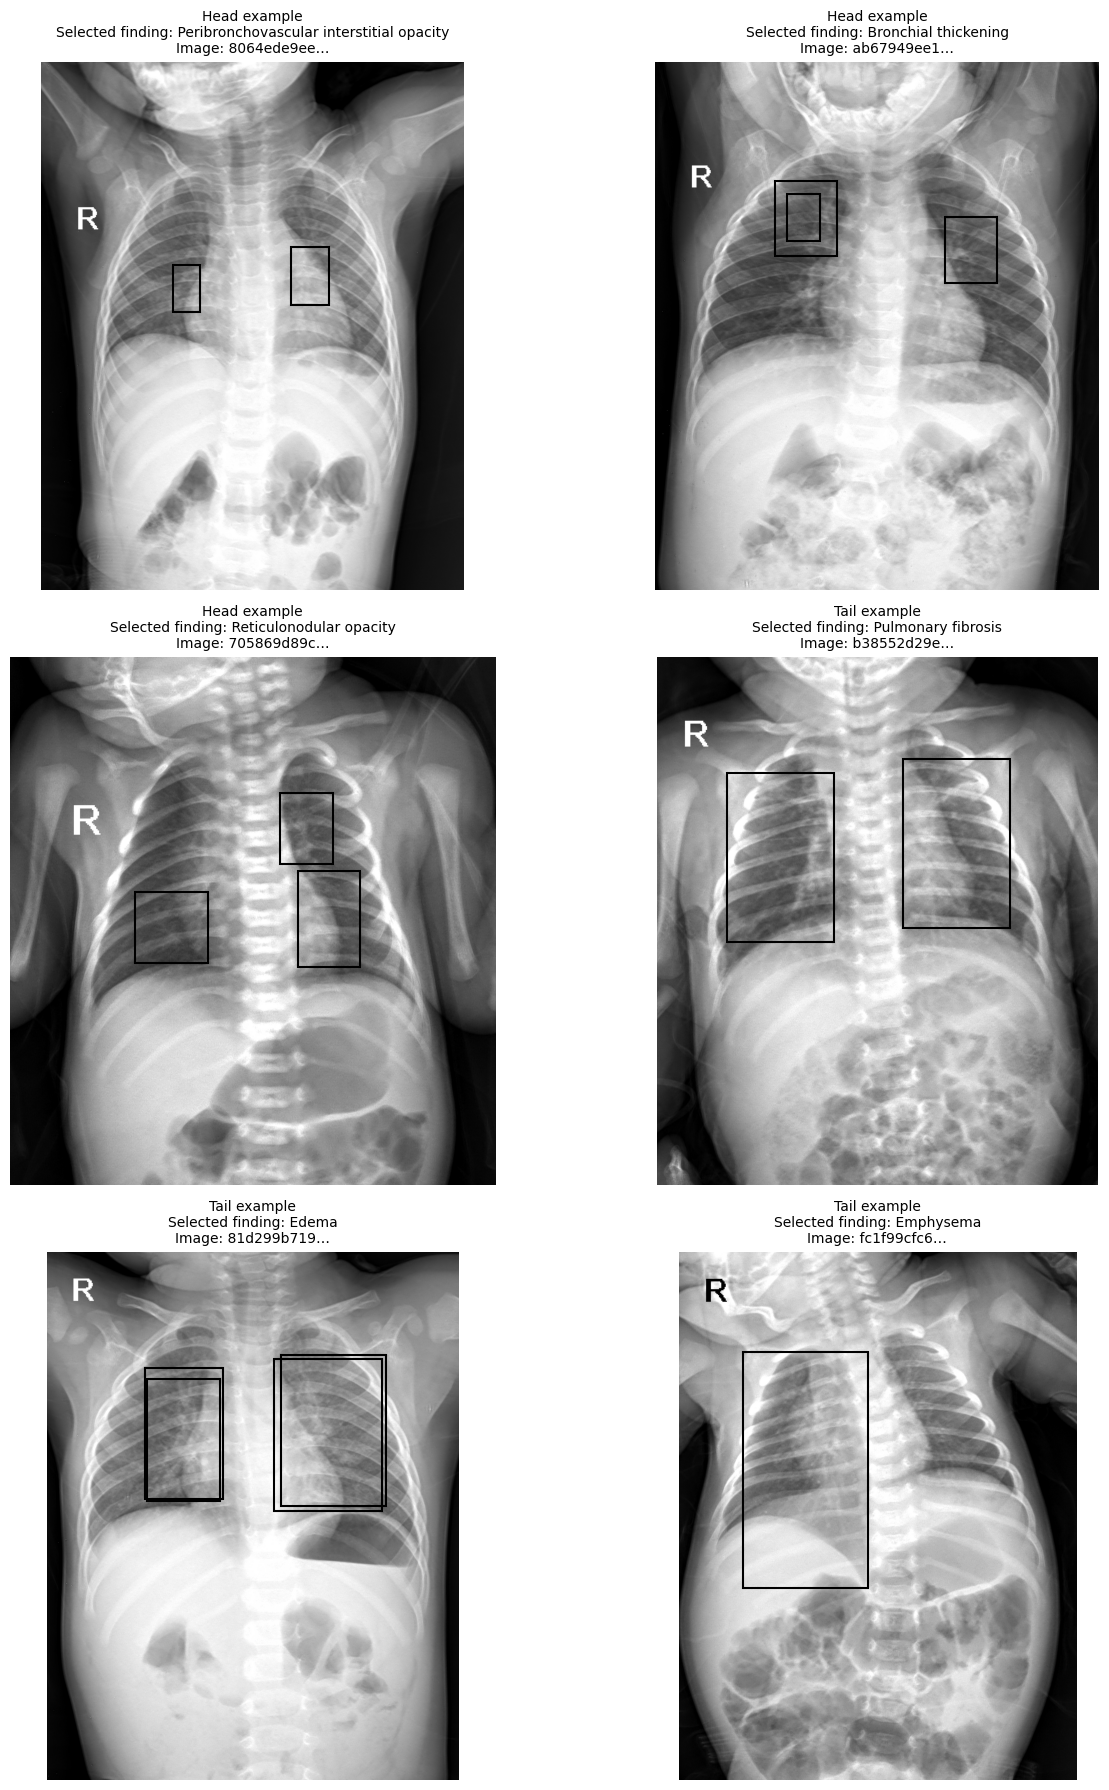

Saved: /kaggle/working/PediCGAM/stage01_eda/figures/09_common_and_rare_box_examples.png


In [29]:
# ============================================================
# 29. Figure — common and rare finding examples with boxes
# ============================================================
if len(sample_manifest_df):
    n = len(sample_manifest_df)
    cols = 2
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(14, 6 * rows)
    )
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (_, sample) in zip(
        axes,
        sample_manifest_df.iterrows()
    ):
        image_id = sample["image_id"]
        image, ds = load_dicom_for_display(image_id)

        ax.imshow(image, cmap="gray")

        boxes = valid_boxes[
            valid_boxes["image_id"] == image_id
        ]

        for _, b in boxes.iterrows():
            rect = plt.Rectangle(
                (b["x_min"], b["y_min"]),
                b["x_max"] - b["x_min"],
                b["y_max"] - b["y_min"],
                fill=False,
                linewidth=1.5
            )
            ax.add_patch(rect)

        ax.set_title(
            f"{sample['rarity_group']} example\n"
            f"Selected finding: {sample['class_name']}\n"
            f"Image: {str(image_id)[:10]}…",
            fontsize=10
        )
        ax.axis("off")

    plt.tight_layout()
    path = FIG_DIR / "09_common_and_rare_box_examples.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


# Part D — Research interpretation

The next section creates a machine-readable and human-readable summary of what the EDA discovered.

The notebook does **not** make final modeling decisions from assumptions. It records the actual measured class counts and candidate rarity groups so we can review them before Stage 02.


In [30]:
# ============================================================
# 30. Build EDA research summary
# ============================================================
rarest_pathologies = (
    pathology_frequency
    .sort_values("positive_images", ascending=True)
    .head(5)
)

most_common_pathologies = (
    pathology_frequency
    .sort_values("positive_images", ascending=False)
    .head(5)
)

rarest_boxed_findings = (
    boxed_findings
    .sort_values("boxed_images", ascending=True)
    .head(5)
)

most_common_boxed_findings = (
    boxed_findings
    .sort_values("boxed_images", ascending=False)
    .head(5)
)

eda_report = {
    "stage": "01_EDA_and_Label_Analysis",
    "data_source": "VinDr-PCXR official training set only",
    "official_test_labels_used": False,
    "training_images": int(len(labels)),
    "image_level_label_count": int(len(LABEL_COLUMNS)),
    "pathology_label_count_excluding_no_finding": int(len(PATHOLOGY_COLUMNS)),
    "annotation_class_count": int(ann["class_name"].nunique()),
    "annotation_rows": int(len(ann)),
    "boxed_annotation_rows": int(ann["has_box"].sum()),
    "images_with_at_least_one_box": int(
        ann.loc[ann["has_box"], "image_id"].nunique()
    ),
    "no_finding_with_pathology_count": no_finding_with_pathology,
    "images_with_multiple_pathologies": int(
        (pathologies_per_image >= 2).sum()
    ),
    "most_common_pathologies": (
        most_common_pathologies[
            ["label", "positive_images"]
        ].to_dict("records")
    ),
    "rarest_pathologies": (
        rarest_pathologies[
            ["label", "positive_images"]
        ].to_dict("records")
    ),
    "most_common_boxed_findings": (
        most_common_boxed_findings[
            ["class_name", "boxed_images"]
        ].to_dict("records")
    ),
    "rarest_boxed_findings": (
        rarest_boxed_findings[
            ["class_name", "boxed_images"]
        ].to_dict("records")
    ),
}

with open(OUTPUT_DIR / "stage01_eda_report.json", "w") as f:
    json.dump(eda_report, f, indent=2)

print(json.dumps(eda_report, indent=2))


{
  "stage": "01_EDA_and_Label_Analysis",
  "data_source": "VinDr-PCXR official training set only",
  "official_test_labels_used": false,
  "training_images": 7728,
  "image_level_label_count": 15,
  "pathology_label_count_excluding_no_finding": 14,
  "annotation_class_count": 37,
  "annotation_rows": 10371,
  "boxed_annotation_rows": 5228,
  "images_with_at_least_one_box": 2585,
  "no_finding_with_pathology_count": 0,
  "images_with_multiple_pathologies": 223,
  "most_common_pathologies": [
    {
      "label": "Bronchitis",
      "positive_images": 842
    },
    {
      "label": "Brocho-pneumonia",
      "positive_images": 545
    },
    {
      "label": "Bronchiolitis",
      "positive_images": 497
    },
    {
      "label": "Other disease",
      "positive_images": 412
    },
    {
      "label": "Pneumonia",
      "positive_images": 392
    }
  ],
  "rarest_pathologies": [
    {
      "label": "Congenital emphysema",
      "positive_images": 2
    },
    {
      "label": "Diagph

In [31]:
# ============================================================
# 31. Create a simple text summary for easy review
# ============================================================
lines = []

lines.append("Pedi-CGAM Lite — Stage 01 EDA Summary")
lines.append("=" * 50)
lines.append("")
lines.append("DATA POLICY")
lines.append("- Official training metadata analyzed.")
lines.append("- Official test labels were NOT loaded.")
lines.append("")
lines.append(f"Training images: {len(labels):,}")
lines.append(f"Image-level output labels: {len(LABEL_COLUMNS)}")
lines.append(
    f"Pathology labels excluding 'No finding': "
    f"{len(PATHOLOGY_COLUMNS)}"
)
lines.append(
    f"Radiological annotation classes: "
    f"{ann['class_name'].nunique()}"
)
lines.append(
    f"Numeric box rows: {int(ann['has_box'].sum()):,}"
)
lines.append(
    f"Images with >=1 box: "
    f"{ann.loc[ann['has_box'], 'image_id'].nunique():,}"
)
lines.append("")
lines.append(
    f"'No finding' + pathology inconsistencies: "
    f"{no_finding_with_pathology}"
)
lines.append(
    f"Images with multiple pathology labels: "
    f"{int((pathologies_per_image >= 2).sum()):,}"
)
lines.append("")
lines.append("RAREST PATHOLOGIES")
for _, row in rarest_pathologies.iterrows():
    lines.append(
        f"- {row['label']}: {int(row['positive_images'])}"
    )
lines.append("")
lines.append("MOST COMMON PATHOLOGIES")
for _, row in most_common_pathologies.iterrows():
    lines.append(
        f"- {row['label']}: {int(row['positive_images'])}"
    )
lines.append("")
lines.append("NEXT STAGE")
lines.append(
    "Review the EDA outputs, then create the fixed "
    "Train / Validation / Calibration split."
)

summary_text = "\n".join(lines)

print(summary_text)

with open(OUTPUT_DIR / "README_STAGE01_RESULTS.txt", "w") as f:
    f.write(summary_text)


Pedi-CGAM Lite — Stage 01 EDA Summary

DATA POLICY
- Official training metadata analyzed.
- Official test labels were NOT loaded.

Training images: 7,728
Image-level output labels: 15
Pathology labels excluding 'No finding': 14
Radiological annotation classes: 37
Numeric box rows: 5,228
Images with >=1 box: 2,585

'No finding' + pathology inconsistencies: 0
Images with multiple pathology labels: 223

RAREST PATHOLOGIES
- Congenital emphysema: 2
- Diagphramatic hernia: 3
- CPAM: 5
- Lung tumor: 5
- Pleuro-pneumonia: 6

MOST COMMON PATHOLOGIES
- Bronchitis: 842
- Brocho-pneumonia: 545
- Bronchiolitis: 497
- Other disease: 412
- Pneumonia: 392

NEXT STAGE
Review the EDA outputs, then create the fixed Train / Validation / Calibration split.


In [32]:
# ============================================================
# 32. Final Stage 01 status
# ============================================================
checks = [
    (
        "Training image count is 7,728",
        len(labels) == 7728
    ),
    (
        "15 image-level labels detected",
        len(LABEL_COLUMNS) == 15
    ),
    (
        "Image-level labels have no missing cells",
        labels[LABEL_COLUMNS].isna().sum().sum() == 0
    ),
    (
        "All training image IDs appear in annotations",
        ann["image_id"].nunique() == 7728
    ),
    (
        "All numeric boxes have valid geometry",
        int(
            (ann["has_box"] & ~ann["valid_box_geometry"]).sum()
        ) == 0
    ),
    (
        "DICOM dimension metadata read succeeded",
        int((~dimensions["metadata_ok"]).sum()) == 0
    ),
]

stage_status = pd.DataFrame(
    checks,
    columns=["check", "passed"]
)
stage_status["status"] = stage_status["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(stage_status)
stage_status.to_csv(
    OUTPUT_DIR / "stage01_final_status.csv",
    index=False
)

if stage_status["passed"].all():
    print("\n✅ STAGE 01 EDA COMPLETED SUCCESSFULLY")
    print(
        "Next: review the real head/middle/tail groups, "
        "then run Stage 02 split creation."
    )
else:
    print("\n⚠️ STAGE 01 HAS ITEMS TO REVIEW")


,check,passed,status
0,"Training image count is 7,728",True,PASS
1,15 image-level labels detected,True,PASS
2,Image-level labels have no missing cells,True,PASS
3,All training image IDs appear in annotations,True,PASS
4,All numeric boxes have valid geometry,True,PASS
5,DICOM dimension metadata read succeeded,True,PASS



✅ STAGE 01 EDA COMPLETED SUCCESSFULLY
Next: review the real head/middle/tail groups, then run Stage 02 split creation.


In [33]:
# ============================================================
# 33. List generated outputs
# ============================================================
print("Generated Stage 01 files:")
print("-" * 80)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            f"{p.relative_to(OUTPUT_DIR)} "
            f"| {p.stat().st_size / (1024**2):.3f} MB"
        )


Generated Stage 01 files:
--------------------------------------------------------------------------------
README_STAGE01_RESULTS.txt | 0.001 MB
figures/01_disease_label_frequency.png | 0.126 MB
figures/02_disease_label_frequency_log_scale.png | 0.123 MB
figures/03_pathologies_per_image.png | 0.062 MB
figures/04_pathology_head_middle_tail.png | 0.133 MB
figures/05_pathology_cooccurrence_heatmap.png | 0.159 MB
figures/06_finding_unique_image_frequency.png | 0.267 MB
figures/07_boxed_finding_frequency.png | 0.262 MB
figures/08_normalized_bounding_box_area.png | 0.061 MB
figures/09_common_and_rare_box_examples.png | 3.889 MB
stage01_eda_report.json | 0.002 MB
stage01_final_status.csv | 0.000 MB
tables/annotation_summary.csv | 0.000 MB
tables/bounding_box_size_statistics.csv | 0.001 MB
tables/bounding_box_stats_by_finding.csv | 0.004 MB
tables/box_visualization_sample_manifest.csv | 0.000 MB
tables/data_quality_summary.csv | 0.000 MB
tables/disease_label_frequency.csv | 0.001 MB
tables/fin

# Final one-click Kaggle export

The final cell packages **every Stage 01 table, figure, and report** into one ZIP.

After the notebook finishes, download:

`PediCGAM_Stage01_EDA_All_Outputs.zip`


In [34]:
# ============================================================
# 34. ZIP ALL STAGE 01 OUTPUTS
# ============================================================
ZIP_BASE = Path(
    "/kaggle/working/PediCGAM_Stage01_EDA_All_Outputs"
)
ZIP_FILE = Path(str(ZIP_BASE) + ".zip")

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(OUTPUT_DIR)
)

print("✅ STAGE 01 ZIP CREATED")
print("File:", ZIP_FILE)
print(
    f"Size: {ZIP_FILE.stat().st_size / (1024**2):.2f} MB"
)
print("\nDownload this one ZIP from Kaggle Output.")


✅ STAGE 01 ZIP CREATED
File: /kaggle/working/PediCGAM_Stage01_EDA_All_Outputs.zip
Size: 5.35 MB

Download this one ZIP from Kaggle Output.


## What to send back after running Stage 01

Send either:

- the executed `.ipynb`, or
- `PediCGAM_Stage01_EDA_All_Outputs.zip`

The most important files will be:

- `README_STAGE01_RESULTS.txt`
- `stage01_eda_report.json`
- `tables/disease_label_frequency.csv`
- `tables/head_middle_tail_pathology_only.csv`
- `tables/finding_frequency_and_box_coverage.csv`
- `tables/head_middle_tail_boxed_findings.csv`
- `tables/bounding_box_size_statistics.csv`
- the generated figures

We will review the measured distribution **before** creating the fixed train / validation / calibration split.
